# Modèle sélectionné et optimisé
## Ici, est présenté le code 'final'

## Contexte métier
Le contexte métier est le suivant : dans un problème de scoring de crédit, accorder un prêt à un client qui fera défaut (faux négatif) est bien plus coûteux que refuser un prêt à un client solvable (faux positif). On estime ici ce coût à 10x supérieur. C'est pourquoi les métriques prioritaires sont le coût métier total (somme pondérée des erreurs), le ratio vs naïf (part du coût d'un modèle qui refuse tout le monde) et le recall de la classe minoritaire (capacité à détecter les clients à risque).

In [29]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.lightgbm
from mlflow.models import infer_signature
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
)
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

from mlflow.tracking import MlflowClient

In [15]:
## chargement des données 
df = pd.read_csv('data/train_engineered.csv')

# LightGBM ne supporte pas les caractères spéciaux JSON dans les noms de colonnes
df.columns = df.columns.str.replace(r'[\[\]{},:"\'\\]', '_', regex=True)

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print('Shape X :', X.shape)
print('Distribution TARGET :\n', y.value_counts())

Shape X : (307511, 396)
Distribution TARGET :
 TARGET
0.0    282686
1.0     24825
Name: count, dtype: int64


In [16]:
## nettoyage des infinis (produits par les agregations dans kernel2)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
print('Infinis restants :', np.isinf(X.select_dtypes('number').values).sum())

Infinis restants : 0


In [18]:
## train/test
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train :', X_train.shape)
print('Val   :', X_val.shape)

Train : (246008, 396)
Val   : (61503, 396)


In [17]:
## On paramètre ML Flow pour notre usage :
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('home-credit-scoring')

mlflow.lightgbm.autolog(
    log_models=False,
    log_input_examples=False,
    log_model_signatures=False
)

## Modèle 1

In [19]:
def cout_metier(y_true, y_pred, cout_fn=10, cout_fp=1):
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    return cout_fn * fn + cout_fp * fp

params = {
    'n_estimators'  : 300,
    'max_depth'     : 5,
    'learning_rate' : 0.05,
    'class_weight'  : 'balanced',
    'random_state'  : 42,
    'n_jobs'        : -1,
}

with mlflow.start_run(run_name='lightgbm_class_weight',
                      tags={'type': 'class_weight', 'seuil': 'optimise_cout_metier'},
                      description='LightGBM avec class_weight=balanced, seuil optimisé sur coût métier FN=10.FP'):

    model_lgbm = LGBMClassifier(**params)
    model_lgbm.fit(X_train, y_train)

    # validation croisée
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model_lgbm, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    mlflow.log_metric('cv_auc_mean', cv_scores.mean())
    mlflow.log_metric('cv_auc_std',  cv_scores.std())

    # probabilités sur val
    y_pred_proba = model_lgbm.predict_proba(X_val)[:, 1]
    mlflow.log_metric('auc',           roc_auc_score(y_val, y_pred_proba))
    mlflow.log_metric('avg_precision', average_precision_score(y_val, y_pred_proba))

    # seuil optimal basé sur le coût métier
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
    couts = []
    for threshold in thresholds:
        y_pred_t = (y_pred_proba > threshold).astype(int)
        couts.append(cout_metier(y_val, y_pred_t))
    optimal_threshold = thresholds[np.argmin(couts)]
    mlflow.log_param('seuil_optimal', round(float(optimal_threshold), 3))

    # métriques au seuil optimal
    y_pred = (y_pred_proba > optimal_threshold).astype(int)
    mlflow.log_metric('recall_minority',    recall_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('precision_minority', precision_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('f1',                f1_score(y_val, y_pred, pos_label=1))

    # coût métier
    cout      = cout_metier(y_val, y_pred)
    cout_naif = cout_metier(y_val, np.zeros(len(y_val)).astype(int))
    ratio_vs_naif = cout / cout_naif
    mlflow.log_metric('cout_metier',   cout)
    mlflow.log_metric('ratio_vs_naif', ratio_vs_naif)

    # artifact : courbe ROC
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_val, y_pred_proba):.3f}')
    ax.axvline(fpr[np.argmin(couts)], color='red', linestyle='--', label=f'Seuil optimal = {optimal_threshold:.3f}')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Courbe ROC - Modèle 1')
    ax.legend()
    fig.tight_layout()
    fig.savefig('/tmp/roc_curve_m1.png')
    plt.close(fig)
    mlflow.log_artifact('/tmp/roc_curve_m1.png', artifact_path='plots')

    # artifact : feature importance top 20
    importances_m1 = pd.Series(model_lgbm.feature_importances_, index=X_train.columns)
    fig, ax = plt.subplots(figsize=(10, 6))
    importances_m1.nlargest(20).sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Top 20 feature importances - Modèle 1')
    fig.tight_layout()
    fig.savefig('/tmp/feature_importance_m1.png')
    plt.close(fig)
    mlflow.log_artifact('/tmp/feature_importance_m1.png', artifact_path='plots')

    # enregistrement dans le Model Registry
    signature = infer_signature(X_val, y_pred_proba)
    mlflow.lightgbm.log_model(
        lgb_model=model_lgbm,
        artifact_path='model',
        registered_model_name='lightgbm-credit-scoring',
        signature=signature,
        input_example=X_val.iloc[:5],
        metadata={
            'seuil_optimal'  : round(float(optimal_threshold), 3),
            'auc'            : round(roc_auc_score(y_val, y_pred_proba), 4),
            'recall_minority': round(recall_score(y_val, y_pred, pos_label=1), 4),
            'cout_fn'        : 10,
            'cout_fp'        : 1,
        },
    )

    print(f'CV AUC        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'AUC val       : {roc_auc_score(y_val, y_pred_proba):.4f}')
    print(f'Seuil optimal : {optimal_threshold:.3f}')
    print(f'Recall        : {recall_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Précision     : {precision_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Ratio vs naïf : {ratio_vs_naif:.3f}')
    print(f'Le modèle coûte {ratio_vs_naif:.0%} du coût d\'un modèle qui ne détecte rien.')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.410057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 47528
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 384
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

2026/07/27 18:15:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 18:15:43 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 18:15:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 18:15:50 INFO mlflow.utils.environment: Detected uv project at /Users/capucinejaud/mlops-1. Attempting to export requirements via 'uv export'.
2026/07/27 18:15:50 INFO mlflow.utils.uv_utils: Exported 193 dependencies via uv
2026/07/27 18:15:50 INFO mlflow.utils.environment: Successfully exported 193 requirements from uv project. Skipping package capture based inference.


CV AUC        : 0.7736 ± 0.0013
AUC val       : 0.7801
Seuil optimal : 0.503
Recall        : 0.686
Précision     : 0.189
Ratio vs naïf : 0.609
Le modèle coûte 61% du coût d'un modèle qui ne détecte rien.


Registered model 'lightgbm-credit-scoring' already exists. Creating a new version of this model...
Created version '7' of model 'lightgbm-credit-scoring'.


## Modèle 2 - suppression features corrélées 
Cela donne un résultat moins bon que le premier modèle ; explication possible :
* LightGBM gère déjà la redondance lui-même
* Corrélation ≠ redondance pour la classe minoritaire

In [55]:
# features avec une corrélation > 0.95 (les quasi doublons) avec au moins une autre feature
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f'Features hautement corrélées (>0.95) : {len(to_drop)}')
print(to_drop[:20])  # affiche les 20 premières

Features hautement corrélées (>0.95) : 64
['AMT_GOODS_PRICE', 'FLAG_EMP_PHONE', 'REGION_RATING_CLIENT_W_CITY', 'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'FLOORSMAX_MEDI', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DAYS_EMPLOYED_ANOM', 'NAME_CONTRACT_TYPE_Revolving loans', 'CODE_GENDER_M', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_Y', 'NAME_INCOME_TYPE_Pensioner', 'ORGANIZATION_TYPE_XNA', 'DAYS_EMPLOYED_PERC', 'BURO_AMT_CREDIT_SUM_DEBT_SUM', 'PREV_AMT_CREDIT_MIN', 'PREV_AMT_CREDIT_MAX', 'PREV_AMT_CREDIT_MEAN']


In [56]:
# on les drop 
to_drop_existing = [col for col in to_drop if col in X_train.columns]

X_train = X_train.drop(columns=to_drop_existing)
X_val   = X_val.drop(columns=to_drop_existing)

print(f'Features restantes : {X_train.shape[1]}')

Features restantes : 332


In [ ]:
## Run MLflow Modèle 2 : entraînement sur les features restantes (corrélées supprimées)
with mlflow.start_run(run_name='lightgbm_drop_correlated',
                      tags={'type': 'feature_selection', 'etape': 'suppression_correlees'},
                      description='LightGBM après suppression des features corrélées >0.95'):

    model_lgbm2 = LGBMClassifier(**params)
    model_lgbm2.fit(X_train, y_train)

    mlflow.log_param('n_features', X_train.shape[1])

    # validation croisée
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model_lgbm2, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    mlflow.log_metric('cv_auc_mean', cv_scores.mean())
    mlflow.log_metric('cv_auc_std',  cv_scores.std())

    # probabilités sur val
    y_pred_proba = model_lgbm2.predict_proba(X_val)[:, 1]
    mlflow.log_metric('auc',           roc_auc_score(y_val, y_pred_proba))
    mlflow.log_metric('avg_precision', average_precision_score(y_val, y_pred_proba))

    # seuil optimal
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
    couts = []
    for threshold in thresholds:
        y_pred_t = (y_pred_proba > threshold).astype(int)
        couts.append(cout_metier(y_val, y_pred_t))
    optimal_threshold = thresholds[np.argmin(couts)]
    mlflow.log_param('seuil_optimal', round(float(optimal_threshold), 3))

    # métriques au seuil optimal
    y_pred = (y_pred_proba > optimal_threshold).astype(int)
    mlflow.log_metric('recall_minority',    recall_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('precision_minority', precision_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('f1',                f1_score(y_val, y_pred, pos_label=1))

    # coût métier
    cout      = cout_metier(y_val, y_pred)
    cout_naif = cout_metier(y_val, np.zeros(len(y_val)).astype(int))
    ratio_vs_naif = cout / cout_naif
    mlflow.log_metric('cout_metier',   cout)
    mlflow.log_metric('ratio_vs_naif', ratio_vs_naif)

    # importances - disponibles pour la sélection suivante
    importances_m2 = pd.Series(model_lgbm2.feature_importances_, index=X_train.columns)

    # artifact : courbe ROC
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_val, y_pred_proba):.3f}')
    ax.axvline(fpr[np.argmin(couts)], color='red', linestyle='--', label=f'Seuil = {optimal_threshold:.3f}')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Courbe ROC - Modèle 2')
    ax.legend(); fig.tight_layout()
    fig.savefig('/tmp/roc_curve_m2.png'); plt.close(fig)
    mlflow.log_artifact('/tmp/roc_curve_m2.png', artifact_path='plots')

    # artifact : feature importance
    fig, ax = plt.subplots(figsize=(10, 6))
    importances_m2.nlargest(20).sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Top 20 feature importances - Modèle 2')
    fig.tight_layout()
    fig.savefig('/tmp/feature_importance_m2.png'); plt.close(fig)
    mlflow.log_artifact('/tmp/feature_importance_m2.png', artifact_path='plots')

    # enregistrement dans le Model Registry
    signature = infer_signature(X_val, y_pred_proba)
    mlflow.lightgbm.log_model(
        lgb_model=model_lgbm2,
        artifact_path='model',
        registered_model_name='lightgbm-credit-scoring',
        signature=signature,
        input_example=X_val.iloc[:5],
        metadata={
            'seuil_optimal'  : round(float(optimal_threshold), 3),
            'auc'            : round(roc_auc_score(y_val, y_pred_proba), 4),
            'recall_minority': round(recall_score(y_val, y_pred, pos_label=1), 4),
            'n_features'     : X_train.shape[1],
            'cout_fn'        : 10,
            'cout_fp'        : 1,
        },
    )

    print(f'N features     : {X_train.shape[1]}')
    print(f'CV AUC         : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'AUC val        : {roc_auc_score(y_val, y_pred_proba):.4f}')
    print(f'Seuil optimal  : {optimal_threshold:.3f}')
    print(f'Recall         : {recall_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Précision      : {precision_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Ratio vs naïf  : {ratio_vs_naif:.3f}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.689419 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34956
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 320
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

2026/07/27 11:42:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 11:42:20 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 11:42:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 11:42:21 INFO mlflow.utils.environment: Detected uv project at /Users/capucinejaud/mlops-1. Attempting to export requirements via 'uv export'.
2026/07/27 11:42:21 INFO mlflow.utils.uv_utils: Exported 188 dependencies via uv
2026/07/27 11:42:21 INFO mlflow.utils.environment: Successfully exported 188 requirements from uv project. Skipping package capture based inference.
2026/07/27 11:42:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


N features     : 332
CV AUC         : 0.7729 ± 0.0017
AUC val        : 0.7793
Seuil optimal  : 0.515
Recall         : 0.667
Précision      : 0.193
Ratio vs naïf  : 0.611


Registered model 'lightgbm-credit-scoring' already exists. Creating a new version of this model...
Created version '3' of model 'lightgbm-credit-scoring'.


## Modèle 3
On oublie le fait d'enlever les features très corrélées et on tente juste d'alléger le modèle. Ca ne donne pas mieux non plus... Explications possibles : 
* L'importance LightGBM est biaisée vers la classe majoritaire
* n_estimators=300 avec sous-échantillonnage aléatoire de features : or, il m'est compliqué de monter + haut à cause des capacités de mon ordinateur...

In [62]:
# exploration des importances du Modèle 2 pour préparer la sélection suivante
print(f'Features à importance nulle : {(importances_m2 == 0).sum()}')
importances_m2.nsmallest(50).sort_values()

Features à importance nulle : 93


FLAG_MOBIL                               0
FLAG_CONT_MOBILE                         0
REG_REGION_NOT_LIVE_REGION               0
REG_REGION_NOT_WORK_REGION               0
FLAG_DOCUMENT_2                          0
FLAG_DOCUMENT_4                          0
FLAG_DOCUMENT_5                          0
FLAG_DOCUMENT_7                          0
FLAG_DOCUMENT_8                          0
FLAG_DOCUMENT_9                          0
FLAG_DOCUMENT_10                         0
FLAG_DOCUMENT_12                         0
FLAG_DOCUMENT_14                         0
FLAG_DOCUMENT_15                         0
FLAG_DOCUMENT_17                         0
FLAG_DOCUMENT_19                         0
FLAG_DOCUMENT_20                         0
FLAG_DOCUMENT_21                         0
AMT_REQ_CREDIT_BUREAU_HOUR               0
AMT_REQ_CREDIT_BUREAU_WEEK               0
FLAG_OWN_REALTY_N                        0
NAME_TYPE_SUITE_Children                 0
NAME_TYPE_SUITE_Family                   0
NAME_TYPE_S

In [63]:
# Garder uniquement les features utilisées au moins une fois par le Modèle 2
useful_features = importances_m2[importances_m2 > 0].index.tolist()
print(f'Features utiles : {len(useful_features)}')

X_train = X_train[useful_features]
X_val   = X_val[useful_features]

Features utiles : 239


In [ ]:
## Run MLflow Modèle 3 : entraînement sur les features restantes (importance nulle supprimées)
with mlflow.start_run(run_name='lightgbm_drop_zero_importance',
                      tags={'type': 'feature_selection', 'etape': 'suppression_importance_nulle'},
                      description='LightGBM après suppression des features à importance nulle'):

    model_lgbm3 = LGBMClassifier(**params)
    model_lgbm3.fit(X_train, y_train)

    mlflow.log_param('n_features', X_train.shape[1])

    # validation croisée
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model_lgbm3, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    mlflow.log_metric('cv_auc_mean', cv_scores.mean())
    mlflow.log_metric('cv_auc_std',  cv_scores.std())

    # probabilités sur val
    y_pred_proba = model_lgbm3.predict_proba(X_val)[:, 1]
    mlflow.log_metric('auc',           roc_auc_score(y_val, y_pred_proba))
    mlflow.log_metric('avg_precision', average_precision_score(y_val, y_pred_proba))

    # seuil optimal
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
    couts = []
    for threshold in thresholds:
        y_pred_t = (y_pred_proba > threshold).astype(int)
        couts.append(cout_metier(y_val, y_pred_t))
    optimal_threshold = thresholds[np.argmin(couts)]
    mlflow.log_param('seuil_optimal', round(float(optimal_threshold), 3))

    # métriques au seuil optimal
    y_pred = (y_pred_proba > optimal_threshold).astype(int)
    mlflow.log_metric('recall_minority',    recall_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('precision_minority', precision_score(y_val, y_pred, pos_label=1))
    mlflow.log_metric('f1',                f1_score(y_val, y_pred, pos_label=1))

    # coût métier
    cout      = cout_metier(y_val, y_pred)
    cout_naif = cout_metier(y_val, np.zeros(len(y_val)).astype(int))
    ratio_vs_naif = cout / cout_naif
    mlflow.log_metric('cout_metier',   cout)
    mlflow.log_metric('ratio_vs_naif', ratio_vs_naif)

    # artifact : courbe ROC
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_val, y_pred_proba):.3f}')
    ax.axvline(fpr[np.argmin(couts)], color='red', linestyle='--', label=f'Seuil = {optimal_threshold:.3f}')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Courbe ROC - Modèle 3')
    ax.legend(); fig.tight_layout()
    fig.savefig('/tmp/roc_curve_m3.png'); plt.close(fig)
    mlflow.log_artifact('/tmp/roc_curve_m3.png', artifact_path='plots')

    # artifact : feature importance
    importances_m3 = pd.Series(model_lgbm3.feature_importances_, index=X_train.columns)
    fig, ax = plt.subplots(figsize=(10, 6))
    importances_m3.nlargest(20).sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Top 20 feature importances - Modèle 3')
    fig.tight_layout()
    fig.savefig('/tmp/feature_importance_m3.png'); plt.close(fig)
    mlflow.log_artifact('/tmp/feature_importance_m3.png', artifact_path='plots')

    # enregistrement dans le Model Registry
    signature = infer_signature(X_val, y_pred_proba)
    mlflow.lightgbm.log_model(
        lgb_model=model_lgbm3,
        artifact_path='model',
        registered_model_name='lightgbm-credit-scoring',
        signature=signature,
        input_example=X_val.iloc[:5],
        metadata={
            'seuil_optimal'  : round(float(optimal_threshold), 3),
            'auc'            : round(roc_auc_score(y_val, y_pred_proba), 4),
            'recall_minority': round(recall_score(y_val, y_pred, pos_label=1), 4),
            'n_features'     : X_train.shape[1],
            'cout_fn'        : 10,
            'cout_fp'        : 1,
        },
    )

    print(f'N features     : {X_train.shape[1]}')
    print(f'CV AUC         : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'AUC val        : {roc_auc_score(y_val, y_pred_proba):.4f}')
    print(f'Seuil optimal  : {optimal_threshold:.3f}')
    print(f'Recall         : {recall_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Précision      : {precision_score(y_val, y_pred, pos_label=1):.3f}')
    print(f'Ratio vs naïf  : {ratio_vs_naif:.3f}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.299203 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33400
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 239
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

2026/07/27 11:56:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 11:56:47 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 11:56:48 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 11:56:48 INFO mlflow.utils.environment: Detected uv project at /Users/capucinejaud/mlops-1. Attempting to export requirements via 'uv export'.
2026/07/27 11:56:48 INFO mlflow.utils.uv_utils: Exported 188 dependencies via uv
2026/07/27 11:56:48 INFO mlflow.utils.environment: Successfully exported 188 requirements from uv project. Skipping package capture based inference.
2026/07/27 11:56:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


N features     : 239
CV AUC         : 0.7726 ± 0.0018
AUC val        : 0.7793
Seuil optimal  : 0.515
Recall         : 0.667
Précision      : 0.193
Ratio vs naïf  : 0.611


Registered model 'lightgbm-credit-scoring' already exists. Creating a new version of this model...
Created version '4' of model 'lightgbm-credit-scoring'.


## Modèle 4 
On reste donc sur le modèle 1, mais on va tenter d'optimiser les hyper-paramètres avec Optuna.

In [70]:
# Repart des 396 features originales 
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# désactive l'autolog pendant Optuna pour éviter de logger des milliers de points par trial
mlflow.lightgbm.autolog(disable=True)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'class_weight'     : 'balanced',
        'random_state'     : 42,
        'n_jobs'           : -1,
    }

    with mlflow.start_run(run_name=f'trial_{trial.number}', nested=True):
        model = LGBMClassifier(**params)
        model.fit(X_train_opt, y_train_opt)

        y_pred_proba = model.predict_proba(X_val_opt)[:, 1]
        auc = roc_auc_score(y_val_opt, y_pred_proba)

        # filtre les solutions dégénérées
        if auc < 0.75:
            mlflow.log_metric('auc', auc)
            mlflow.log_metric('cout_metier', float('inf'))
            return float('inf')

        # seuil optimal
        fpr, tpr, thresholds = roc_curve(y_val_opt, y_pred_proba)
        couts = [cout_metier(y_val_opt, (y_pred_proba > t).astype(int)) for t in thresholds]
        optimal_threshold = thresholds[np.argmin(couts)]
        y_pred = (y_pred_proba > optimal_threshold).astype(int)
        cout = cout_metier(y_val_opt, y_pred)

        mlflow.log_params(params)
        mlflow.log_metric('auc',             auc)
        mlflow.log_metric('cout_metier',     cout)
        mlflow.log_metric('recall_minority', recall_score(y_val_opt, y_pred, pos_label=1))
        mlflow.log_metric('seuil_optimal',   round(float(optimal_threshold), 3))

    return cout

with mlflow.start_run(run_name='optuna_lightgbm',
                      tags={'type': 'optuna'},
                      description='Optimisation Optuna sur 396 features, 30 trials, métrique : coût métier (FN=10.FP)'):

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    best = study.best_trial
    print(f'\nMeilleur coût métier : {best.value}')
    print(f'Meilleurs params     : {best.params}')

    mlflow.log_metric('best_cout_metier', best.value)
    mlflow.log_params({f'best_{k}': v for k, v in best.params.items()})

# réactive l'autolog pour la suite
mlflow.lightgbm.autolog(log_models=False, log_input_examples=False, log_model_signatures=False)

  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.414278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 47512
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 376
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [32]:
## Si on ne veut pas refaire tourner optuna 
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Meilleurs hyperparamètres trouvés par Optuna (30 trials, coût métier 29915)
best_params_optuna = {
    'n_estimators'     : 398,
    'max_depth'        : 3,
    'num_leaves'       : 119,
    'learning_rate'    : 0.12410214049339299,
    'min_child_samples': 45,
    'subsample'        : 0.6541145684135494,
    'colsample_bytree' : 0.7383830850565832,
}

# Si Optuna a tourné, on prend ses résultats ; sinon on utilise les params ci-dessus
try:
    study
    best_params = {**study.best_params, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
    print(f'Params Optuna (coût métier = {study.best_value})')
except NameError:
    best_params = {**best_params_optuna, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
    print('Optuna non exécuté ; params sauvegardés utilisés')

print(best_params)


Optuna non exécuté ; params sauvegardés utilisés
{'n_estimators': 398, 'max_depth': 3, 'num_leaves': 119, 'learning_rate': 0.12410214049339299, 'min_child_samples': 45, 'subsample': 0.6541145684135494, 'colsample_bytree': 0.7383830850565832, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}


In [ ]:
with mlflow.start_run(run_name='lightgbm_optuna_best',
                      tags={'type': 'optuna_best', 'seuil': 'optimise_cout_metier'},
                      description='LightGBM avec meilleurs hyperparamètres Optuna (30 trials, coût métier)'):

    model_lgbm4 = LGBMClassifier(**best_params)
    model_lgbm4.fit(X_train_opt, y_train_opt)

    y_pred_proba = model_lgbm4.predict_proba(X_val_opt)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_val_opt, y_pred_proba)
    couts = [cout_metier(y_val_opt, (y_pred_proba > t).astype(int)) for t in thresholds]
    optimal_threshold = thresholds[np.argmin(couts)]
    y_pred = (y_pred_proba > optimal_threshold).astype(int)

    mlflow.log_params(best_params)
    mlflow.log_param('seuil_optimal',       round(float(optimal_threshold), 3))
    mlflow.log_metric('auc',                roc_auc_score(y_val_opt, y_pred_proba))
    mlflow.log_metric('avg_precision',      average_precision_score(y_val_opt, y_pred_proba))
    mlflow.log_metric('recall_minority',    recall_score(y_val_opt, y_pred, pos_label=1))
    mlflow.log_metric('precision_minority', precision_score(y_val_opt, y_pred, pos_label=1))
    mlflow.log_metric('f1',                 f1_score(y_val_opt, y_pred, pos_label=1))

    cout      = cout_metier(y_val_opt, y_pred)
    cout_naif = cout_metier(y_val_opt, np.zeros(len(y_val_opt)).astype(int))
    mlflow.log_metric('cout_metier',   cout)
    mlflow.log_metric('ratio_vs_naif', cout / cout_naif)

    # artifact : courbe ROC
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_val_opt, y_pred_proba):.3f}')
    ax.axvline(fpr[np.argmin(couts)], color='red', linestyle='--', label=f'Seuil = {optimal_threshold:.3f}')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Courbe ROC - Modèle 4 Optuna')
    ax.legend(); fig.tight_layout()
    fig.savefig('/tmp/roc_curve_m4.png'); plt.close(fig)
    mlflow.log_artifact('/tmp/roc_curve_m4.png', artifact_path='plots')

    # enregistrement dans le Model Registry
    signature = infer_signature(X_val_opt, y_pred_proba)
    mlflow.lightgbm.log_model(
        lgb_model=model_lgbm4,
        artifact_path='model',
        registered_model_name='lightgbm-credit-scoring',
        signature=signature,
        input_example=X_val_opt.iloc[:5],
        metadata={
            'seuil_optimal'  : round(float(optimal_threshold), 3),
            'auc'            : round(roc_auc_score(y_val_opt, y_pred_proba), 4),
            'recall_minority': round(recall_score(y_val_opt, y_pred, pos_label=1), 4),
            'cout_fn'        : 10,
            'cout_fp'        : 1,
        },
    )

    print(f'AUC val       : {roc_auc_score(y_val_opt, y_pred_proba):.4f}')
    print(f'Seuil optimal : {optimal_threshold:.3f}')
    print(f'Recall        : {recall_score(y_val_opt, y_pred, pos_label=1):.3f}')
    print(f'Précision     : {precision_score(y_val_opt, y_pred, pos_label=1):.3f}')
    print(f'Ratio vs naïf : {cout / cout_naif:.3f}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.674425 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47522
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 381
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

2026/07/27 18:20:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 18:20:08 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 18:20:09 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 18:20:09 INFO mlflow.utils.environment: Detected uv project at /Users/capucinejaud/mlops-1. Attempting to export requirements via 'uv export'.
2026/07/27 18:20:09 INFO mlflow.utils.uv_utils: Exported 193 dependencies via uv
2026/07/27 18:20:09 INFO mlflow.utils.environment: Successfully exported 193 requirements from uv project. Skipping package capture based inference.


AUC val       : 0.7831
Seuil optimal : 0.499
Recall        : 0.702
Précision     : 0.187
Ratio vs naïf : 0.603


Registered model 'lightgbm-credit-scoring' already exists. Creating a new version of this model...
Created version '8' of model 'lightgbm-credit-scoring'.


In [30]:
client = MlflowClient()

# Description du registered model
client.update_registered_model(
    name="lightgbm-credit-scoring",
    description=(
        "Modèle LightGBM de credit scoring (Home Credit dataset) "
        "Optimisé via Optuna (30 trials) sur le coût métier (FN=10.FP) "
        "Seuil de décision optimisé post-entraînement"
    )
)

# Alias sur la dernière version pour identifier le modèle gagnant
latest_version = client.get_registered_model("lightgbm-credit-scoring").latest_versions[-1].version
client.set_registered_model_alias(
    name="lightgbm-credit-scoring",
    alias="gagnant",
    version=latest_version
)

print(f"Modèle enregistré avec alias gagnant --> version {latest_version}")


Modèle enregistré avec alias gagnant --> version 8


RQ : on n'a pas mis la validation croisée pour ce modèle car le temps d'entraînement aurait été beaucoup trop important.  
Ce modèle performe mieux que le modèle 1 en tous points!

Le Modèle 4 (Optuna) est le meilleur obtenu : une AUC de 0.783 indique une bonne capacité discriminante globale, et un recall de 0.702 signifie que le modèle détecte 70% des clients qui feront réellement défaut, et c'est par ailleurs l'objectif prioritaire. La précision de 0.196 est faible (beaucoup de faux positifs, i.e. bons clients refusés), mais c'est un compromis acceptable étant donné le coût asymétrique entre les deux types d'erreur. Au final, le ratio vs naïf de 0.603 signifie que le modèle réduit de 40% le coût total par rapport à un modèle qui refuserait tous les crédits et c'est le meilleur résultat obtenu sur l'ensemble des modèles testés.  
Le seuil de décision a été optimisé sur le coût métier. Le seuil retenu pour le Modèle 4 est 0.499 (donc presque 0.5). 

## Interprétation métier

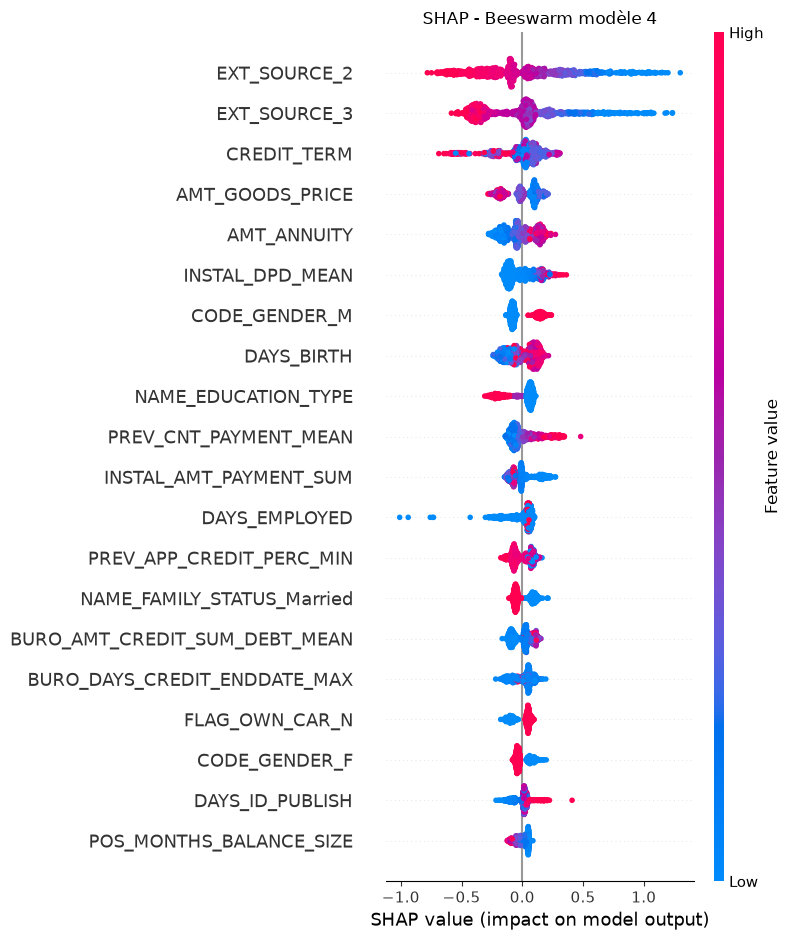

In [22]:
import shap

explainer = shap.TreeExplainer(model_lgbm4)

X_sample = X_val_opt.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Beeswarm 
shap.summary_plot(sv, X_sample, max_display=20, show=False)
plt.title('SHAP - Beeswarm modèle 4')
plt.tight_layout()
plt.show()


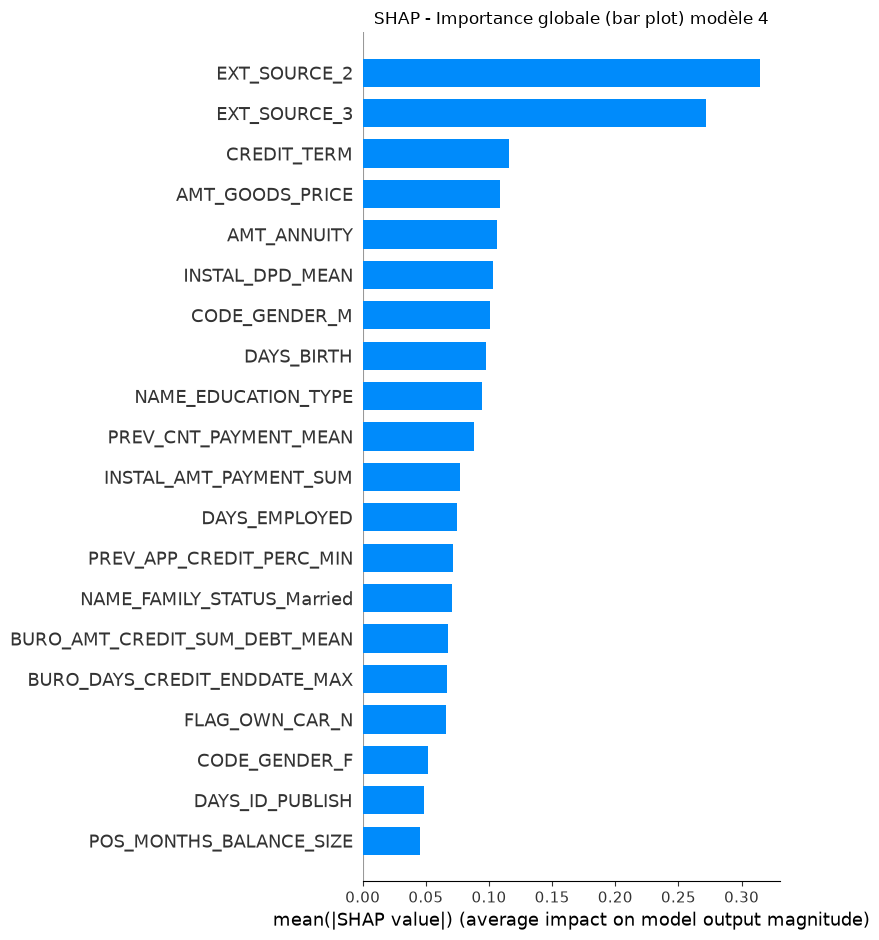

In [ ]:
# Bar plot 
shap.summary_plot(sv, X_sample, plot_type='bar', max_display=20, show=False)
plt.title('SHAP - Importance globale (bar plot) modèle 4')
plt.tight_layout()
plt.show()


L'analyse SHAP globale révèle des facteurs cohérents avec la logique métier : les scores de crédit externes (EXT_SOURCE_2 et 3) dominent largement, ce qui est attendu car ce sont des synthèses d'historique de crédit produites par des bureaux spécialisés. Le ratio mensualité/montant total (CREDIT_TERM) et la mensualité absolue (AMT_ANNUITY) indiquent que la charge de remboursement relative au capital est un signal fort de risque, ce qui semble logique : un client qui rembourse beaucoup par rapport à ce qu'il emprunte est sous pression financière. La moyenne des retards de paiement passés (INSTAL_DPD_MEAN) est également très discriminante, ce qui est encore une fois attendu : un mauvais payeur par le passé a plus de chances de faire défaut. Enfin, le genre masculin (CODE_GENDER_M) ressort comme facteur de risque, un résultat documenté dans la littérature.

Faux négatifs : 25


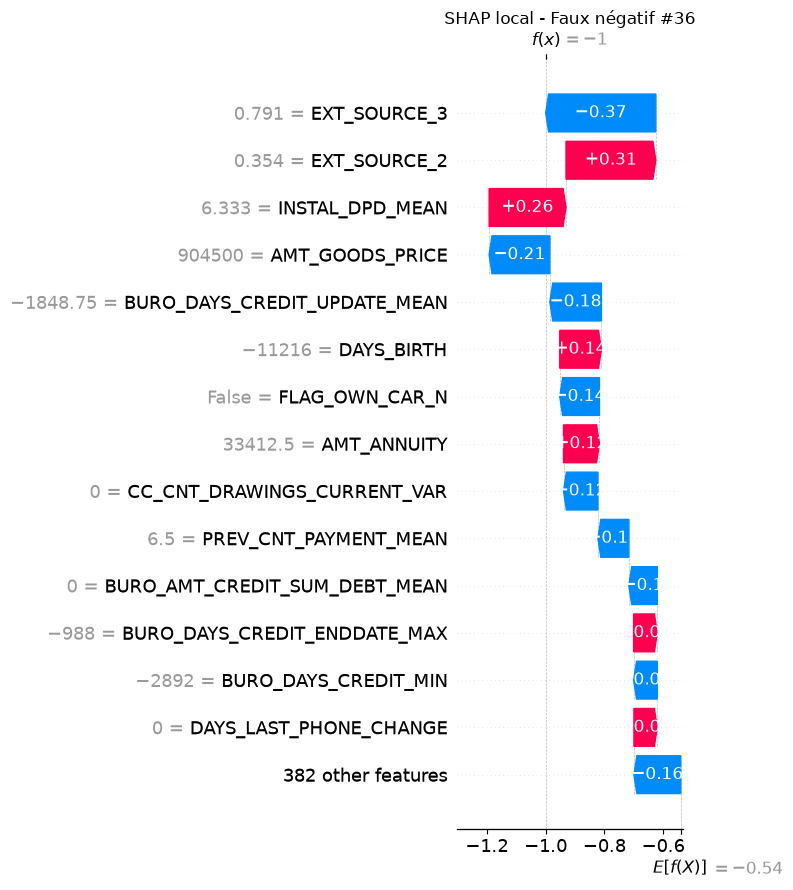

In [25]:
# Importance locale : analyse d'un faux négatif 
# On récupère les faux négatifs dans X_sample
y_sample = y_val_opt.loc[X_sample.index]
y_pred_sample = (model_lgbm4.predict_proba(X_sample)[:, 1] > optimal_threshold).astype(int)

fn_mask = (y_pred_sample == 0) & (y_sample.values == 1)
print(f'Faux négatifs : {fn_mask.sum()}')

# Premier faux négatif
fn_idx = np.where(fn_mask)[0][0]
fn_row = X_sample.iloc[[fn_idx]]

# Waterfall plot SHAP pour cet individu
fn_shap = explainer(fn_row)
shap.plots.waterfall(fn_shap[0], max_display=15, show=False)
plt.title(f'SHAP local - Faux négatif #{fn_idx}')
plt.tight_layout()
plt.savefig('/tmp/shap_waterfall_fn.png', dpi=150, bbox_inches='tight')
plt.show()


* Localement, pour le client 36, le modèle a été trompé par un très bon EXT_SOURCE_3 (0.791, quasi maximal) malgré un historique de retards réels (INSTAL_DPD_MEAN = 6.3). C'est un cas où les scores externes ont masqué un comportement de paiement problématique.

## Serving MLflow
On enregistre une version pyfunc du modèle qui retourne des probabilités (et non des classes binaires) pour pouvoir la servir via API REST.

In [26]:
import mlflow.pyfunc
import tempfile, os

class LGBMProbaWrapper(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        self.model = mlflow.lightgbm.load_model(context.artifacts["lgbm_model"])

    def predict(self, context, model_input):
        return self.model.predict_proba(model_input)[:, 1]

# Sauvegarde temporaire du modèle entraîné pour en faire un artifact
with tempfile.TemporaryDirectory() as tmp_dir:
    model_path = os.path.join(tmp_dir, "lgbm_model")
    mlflow.lightgbm.save_model(model_lgbm4, model_path)

    with mlflow.start_run(run_name="lightgbm_pyfunc_serving",
                          tags={"type": "serving"},
                          description="Wrapper pyfunc du Modèle 4 pour serving REST (retourne des probabilités)"):

        mlflow.pyfunc.log_model(
            artifact_path="model",
            python_model=LGBMProbaWrapper(),
            artifacts={"lgbm_model": model_path},
            registered_model_name="lightgbm-credit-scoring-serving",
            signature=infer_signature(X_val_opt, model_lgbm4.predict_proba(X_val_opt.iloc[:5])[:, 1]),
            input_example=X_val_opt.iloc[:5],
        )

        print("Modèle pyfunc enregistré dans le registry : lightgbm-credit-scoring-serving")


/Users/capucinejaud/mlops-1/.venv/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/07/27 19:41:51 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 19:41:51 INFO mlflow.utils.environment: Detected uv project at /Users/capucinejaud/mlops-1. Attempting to export requirements via 'uv export'.
2026/07/27 19:41:52 INFO mlflow.utils.uv_utils: Exported 193 dependencies via uv
2026/07/27 19:41:52 INFO mlflow.utils.environment: Successfully exported 193 requirements from uv project. Skipping package capture based inference.
2026/07/27 19:42:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/

2026/07/27 19:42:19 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 19:42:19 INFO mlflow.utils.environment: Detected uv project at /Users/capucinejaud/mlops-1. Attempting to export requirements via 'uv export'.
2026/07/27 19:42:19 INFO mlflow.utils.uv_utils: Exported 193 dependencies via uv
2026/07/27 19:42:19 INFO mlflow.utils.environment: Successfully exported 193 requirements from uv project. Skipping package capture based inference.
2026/07/27 19:42:20 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/capucinejaud/mlops-1
2026/07/27 19:42:20 INFO mlflow.utils.uv_utils: Copied uv.lock to model artifacts
2026/07/27 19:42:20 INFO mlflow.utils.uv_utils: Copied pyproject.toml to model artifacts
2026/07/27 19:42:20 INFO mlflow.utils.uv_utils: Copied .python-version to model artifacts


Modèle pyfunc enregistré dans le registry : lightgbm-credit-scoring-serving


Successfully registered model 'lightgbm-credit-scoring-serving'.
Created version '1' of model 'lightgbm-credit-scoring-serving'.


In [31]:
# Description du registered model
client.update_registered_model(
    name="lightgbm-credit-scoring-serving",
    description=(
        "Wrapper pyfunc de lightgbm-credit-scoring@gagnant pour serving REST. "
        "Retourne les probabilités de défaut."
    )
)


<RegisteredModel: aliases={}, creation_timestamp=1785174141606, deployment_job_id=None, deployment_job_state=None, description=('Wrapper pyfunc de lightgbm-credit-scoring@gagnant pour serving REST. '
 'Retourne les probabilités de défaut.'), last_updated_timestamp=1785177259121, latest_versions=[<ModelVersion: aliases=[], creation_timestamp=1785174141631, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1785174141631, metrics=None, model_id=None, name='lightgbm-credit-scoring-serving', params=None, run_id='f5821bffb6014cb6b2ff025ade2702f4', run_link=None, source='models:/m-922f8d1ab6d24f3d8c4a35f9cf2aefbd', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>], name='lightgbm-credit-scoring-serving', tags={}, workspace='default'>

In [ ]:
# Lancer le serveur dans le terminal :
# ! uv run mlflow models serve -m "models:/lightgbm-credit-scoring-serving/1" --port 5001 --no-conda

# Tester avec quelques clients du jeu de validation
import requests

sample = X_val_opt.iloc[:5]
payload = {"dataframe_split": {"columns": sample.columns.tolist(), "data": sample.values.tolist()}}

response = requests.post("http://127.0.0.1:5001/invocations", json=payload)
probas = response.json()["predictions"]

for i, p in enumerate(probas):
    decision = "REFUSE" if p > optimal_threshold else "ACCORDE"
    print(f"Client {i} | proba défaut = {p:.3f} | décision = {decision}")


Client 0 | proba défaut = 0.155 | décision = ACCORDE
Client 1 | proba défaut = 0.406 | décision = ACCORDE
Client 2 | proba défaut = 0.853 | décision = REFUSE
Client 3 | proba défaut = 0.400 | décision = ACCORDE
Client 4 | proba défaut = 0.596 | décision = REFUSE
